# Practical 3 — Basic MLP for Handwritten Digit Recognition (MNIST)

**Objectives:**
- Design and implement 3 MLP architectures (shallow → deep)
- Train on MNIST handwritten digit dataset
- Analyze performance using accuracy, confusion matrix, F1-score
- Compare architectures and understand the effect of depth

> ⚡ Enable GPU: `Runtime → Change runtime type → GPU → Save`

---
## SECTION 1 — Imports & GPU Check

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.titlesize']  = 11
plt.rcParams['axes.titleweight']= 'bold'

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))
print('All imports successful ✅')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful ✅


---
## SECTION 2 — Load & Preprocess MNIST

In [ ]:
# Load dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print('Raw shapes:')
print(f'  X_train : {X_train_raw.shape}  |  y_train : {y_train_raw.shape}')
print(f'  X_test  : {X_test_raw.shape}  |  y_test  : {y_test_raw.shape}')
print(f'  Pixel range before: {X_train_raw.min()} – {X_train_raw.max()}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Raw shapes:
  X_train : (60000, 28, 28)  |  y_train : (60000,)
  X_test  : (10000, 28, 28)  |  y_test  : (10000,)
  Pixel range before: 0 – 255


In [ ]:
# ── Preprocessing Pipeline ───────────────────────────────────
#  Step 1: Flatten  (28,28) → (784,)
#  Step 2: Normalize  /255  → (0.0–1.0)
#  Step 3: One-Hot Encode labels

# Flatten + Normalize
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype('float32')  / 255.0

# One-hot encode
y_train = to_categorical(y_train_raw, num_classes=10)
y_test  = to_categorical(y_test_raw,  num_classes=10)

print('After preprocessing:')
print(f'  X_train : {X_train.shape}  (flattened + normalized)')
print(f'  X_test  : {X_test.shape}')
print(f'  Pixel range after : {X_train.min():.1f} – {X_train.max():.1f}')
print(f'  y_train shape     : {y_train.shape}  (one-hot encoded)')
print(f'\nExample label: raw={y_train_raw[0]}  →  one-hot={y_train[0]}')

After preprocessing:
  X_train : (60000, 784)  (flattened + normalized)
  X_test  : (10000, 784)
  Pixel range after : 0.0 – 1.0
  y_train shape     : (60000, 10)  (one-hot encoded)

Example label: raw=5  →  one-hot=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


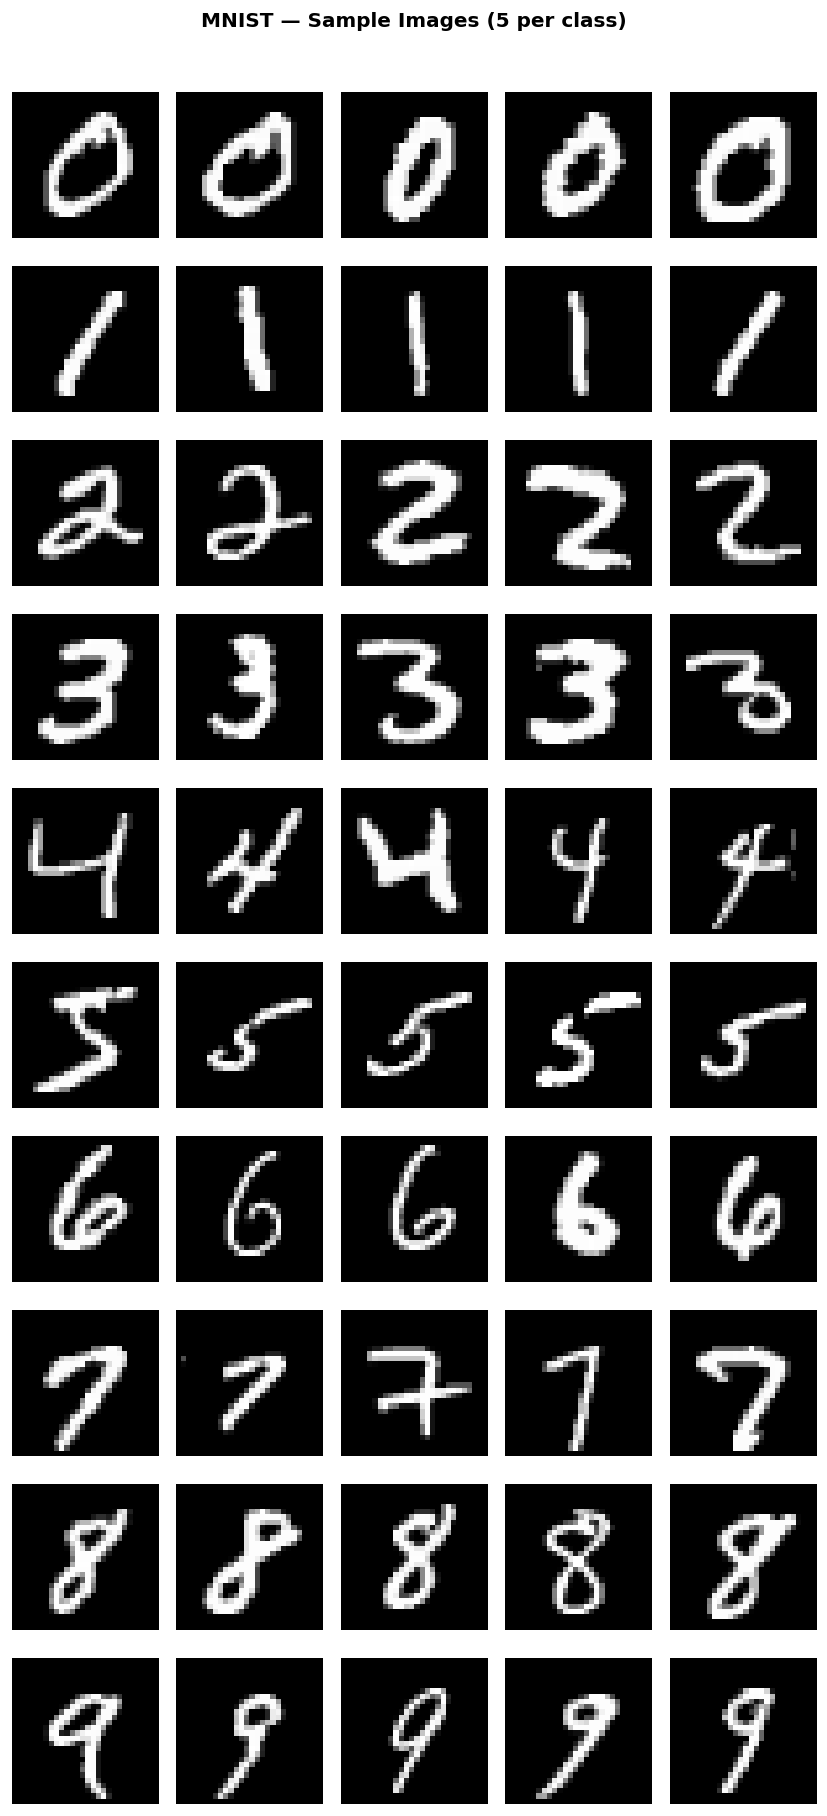

In [ ]:
# Visualize 5 samples per digit class
fig, axes = plt.subplots(10, 5, figsize=(7, 15))
fig.suptitle('MNIST — Sample Images (5 per class)', fontsize=12, fontweight='bold', y=1.01)
for cls in range(10):
    idxs = np.where(y_train_raw == cls)[0][:5]
    for j, idx in enumerate(idxs):
        ax = axes[cls][j]
        ax.imshow(X_train_raw[idx], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'{cls}', rotation=0, labelpad=18,
                          fontsize=11, fontweight='bold', va='center')
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 3 — Define MLP Architectures

Three models with increasing depth:

| Model | Layers | Neurons | Purpose |
|-------|--------|---------|--------|
| A — Shallow | 1 hidden | 128 | Baseline |
| B — Medium  | 2 hidden | 256→128 | Balanced |
| C — Deep    | 3 hidden | 512→256→128 | Best performance |

In [ ]:
def build_model_A():
    """Shallow MLP — 1 hidden layer (baseline)"""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Model_A_Shallow')
    return model

def build_model_B():
    """Medium MLP — 2 hidden layers"""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Model_B_Medium')
    return model

def build_model_C():
    """Deep MLP — 3 hidden layers"""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Model_C_Deep')
    return model

# Print architecture summaries
for name, fn in [('A — Shallow', build_model_A),
                  ('B — Medium',  build_model_B),
                  ('C — Deep',    build_model_C)]:
    m = fn()
    print(f'\n{'='*45}')
    print(f'  MODEL {name}')
    print(f'{'='*45}')
    m.summary()
    print(f'  Total params: {m.count_params():,}')


  MODEL A — Shallow


Model: "Model_A_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

  Total params: 567,434


---
## SECTION 4 — Train All Three Models

In [ ]:
# ── Shared training settings ─────────────────────────────────
EPOCHS     = 25
BATCH_SIZE = 128
VAL_SPLIT  = 0.2   # 20% of training data used for validation

def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        )
    ]

def compile_and_train(model, name):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'\n Training {name}...')
    t0      = time.time()
    history = model.fit(
        X_train, y_train,
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_split= VAL_SPLIT,
        callbacks       = get_callbacks(),
        verbose         = 1
    )
    elapsed = time.time() - t0
    print(f' Done in {elapsed:.1f}s')
    return history, elapsed

# Train all models
model_A = build_model_A()
hist_A, time_A = compile_and_train(model_A, 'Model A — Shallow')

model_B = build_model_B()
hist_B, time_B = compile_and_train(model_B, 'Model B — Medium')

model_C = build_model_C()
hist_C, time_C = compile_and_train(model_C, 'Model C — Deep')


 Training Model A — Shallow...
Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8930 - loss: 0.3884 - val_accuracy: 0.9403 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9465 - loss: 0.1863 - val_accuracy: 0.9536 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9607 - loss: 0.1374 - val_accuracy: 0.9609 - val_loss: 0.1340 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.1081 - val_accuracy: 0.9653 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0878 - val_accuracy: 0.9682 - val_loss: 0.1093 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9802 - loss: 0.0729 - val_accuracy: 0.9704 - val_loss: 0.1030 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - ac

---
## SECTION 5 — Training Curves Analysis

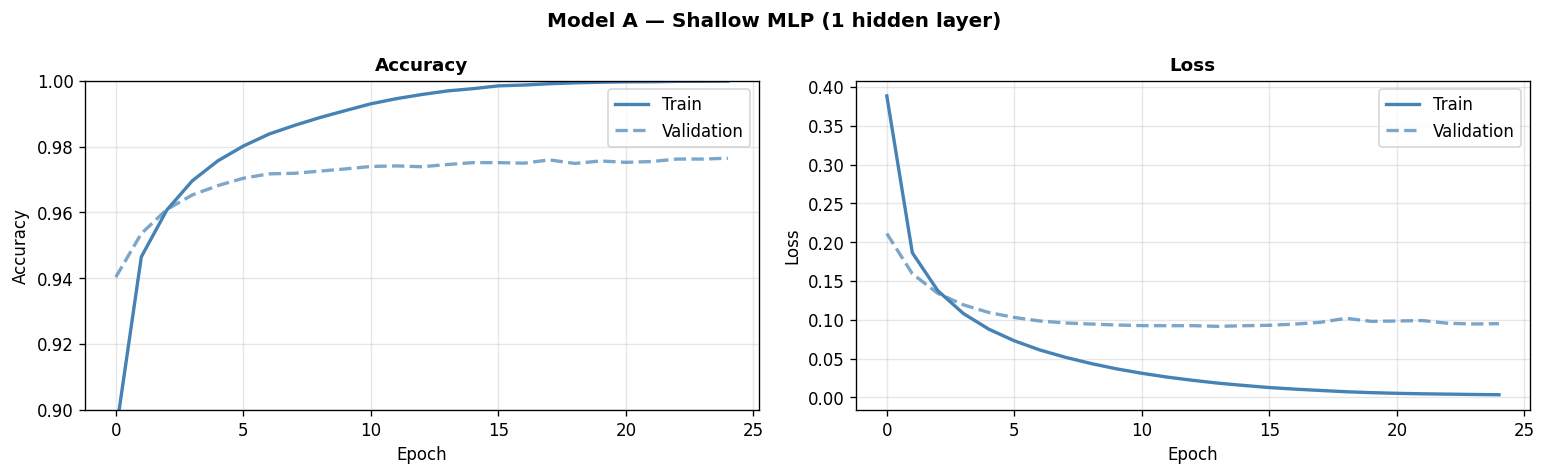

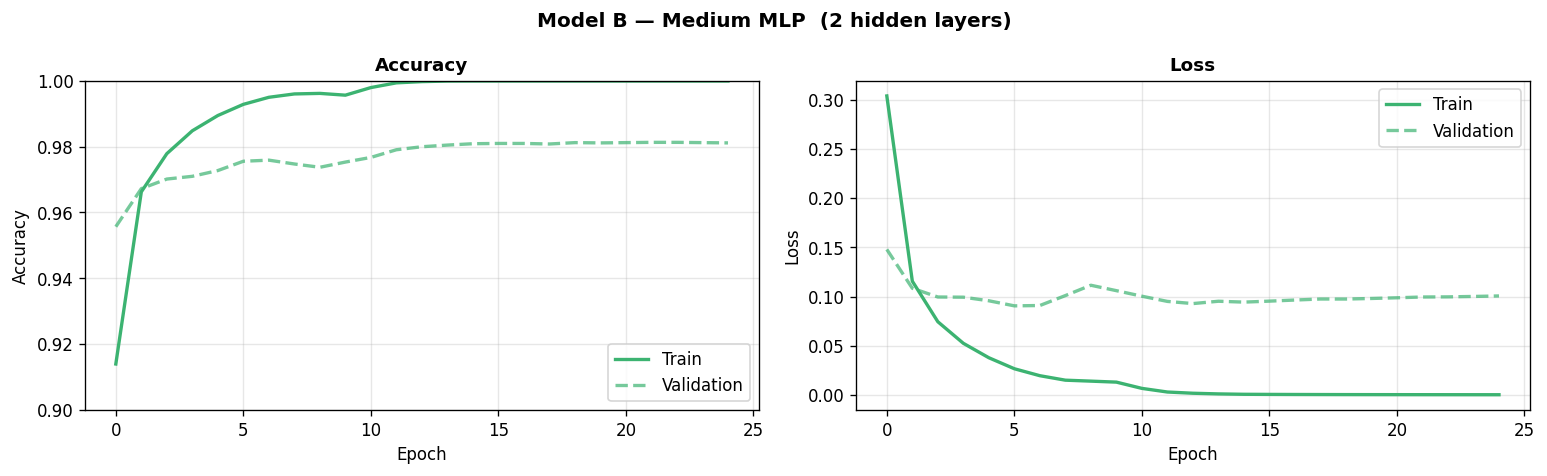

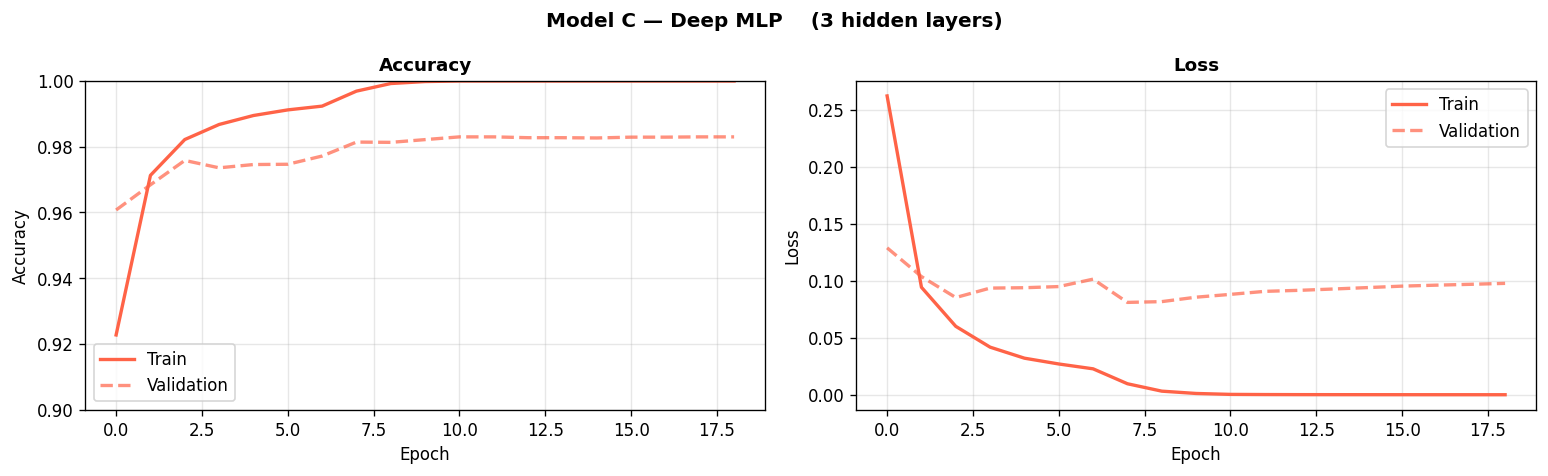

In [ ]:
# ── Plot training curves for all 3 models ───────────────────
def plot_history(history, title, color):
    h = history.history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    ax1.plot(h['accuracy'],     label='Train',      color=color,  linewidth=2)
    ax1.plot(h['val_accuracy'], label='Validation', color=color,  linewidth=2,
             linestyle='--', alpha=0.7)
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0.9, 1.0)

    ax2.plot(h['loss'],     label='Train',      color=color,  linewidth=2)
    ax2.plot(h['val_loss'], label='Validation', color=color,  linewidth=2,
             linestyle='--', alpha=0.7)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = title.replace(' ', '_').replace('—','').replace('(','').replace(')','') + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(hist_A, 'Model A — Shallow MLP (1 hidden layer)', 'steelblue')
plot_history(hist_B, 'Model B — Medium MLP  (2 hidden layers)', 'mediumseagreen')
plot_history(hist_C, 'Model C — Deep MLP    (3 hidden layers)', 'tomato')

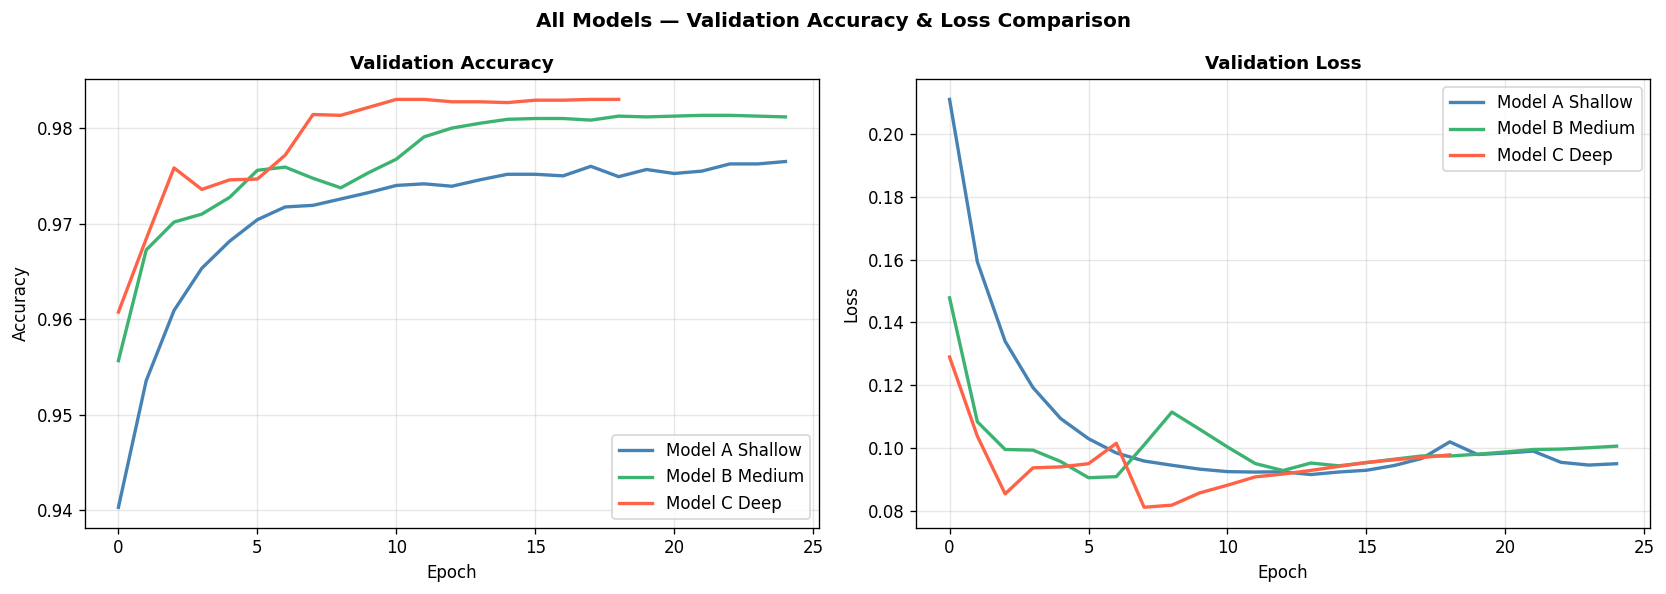

In [ ]:
# All 3 models on same plot for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Models — Validation Accuracy & Loss Comparison', fontsize=12, fontweight='bold')

styles = [
    (hist_A, 'Model A Shallow', 'steelblue'),
    (hist_B, 'Model B Medium',  'mediumseagreen'),
    (hist_C, 'Model C Deep',    'tomato'),
]
for hist, label, color in styles:
    ax1.plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)
    ax2.plot(hist.history['val_loss'],     label=label, color=color, linewidth=2)

ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 6 — Evaluate on Test Set

In [ ]:
# Evaluate all models on test set
results = {}
print('='*62)
print('  TEST SET EVALUATION')
print('='*62)
print(f'  {"Model":<22} {"Accuracy":>10} {"Loss":>10} {"Params":>12} {"Time":>8}')
print('-'*62)

for model, hist, name, t in [
    (model_A, hist_A, 'A — Shallow', time_A),
    (model_B, hist_B, 'B — Medium',  time_B),
    (model_C, hist_C, 'C — Deep',    time_C),
]:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)
    results[name] = {
        'model': model, 'acc': acc, 'loss': loss,
        'y_pred': y_pred, 'params': model.count_params(), 'time': t
    }
    print(f'  {name:<22} {acc*100:>9.2f}% {loss:>10.4f} {model.count_params():>12,} {t:>7.1f}s')

print('='*62)
best = max(results, key=lambda k: results[k]['acc'])
print(f'\n  🏆 Best Model: {best}  ({results[best]["acc"]*100:.2f}% accuracy)')

  TEST SET EVALUATION
  Model                    Accuracy       Loss       Params     Time
--------------------------------------------------------------
  A — Shallow                97.83%     0.0884      101,770    36.7s
  B — Medium                 98.09%     0.0875      235,146    39.0s
  C — Deep                   98.40%     0.0779      567,434    32.1s

  🏆 Best Model: C — Deep  (98.40% accuracy)


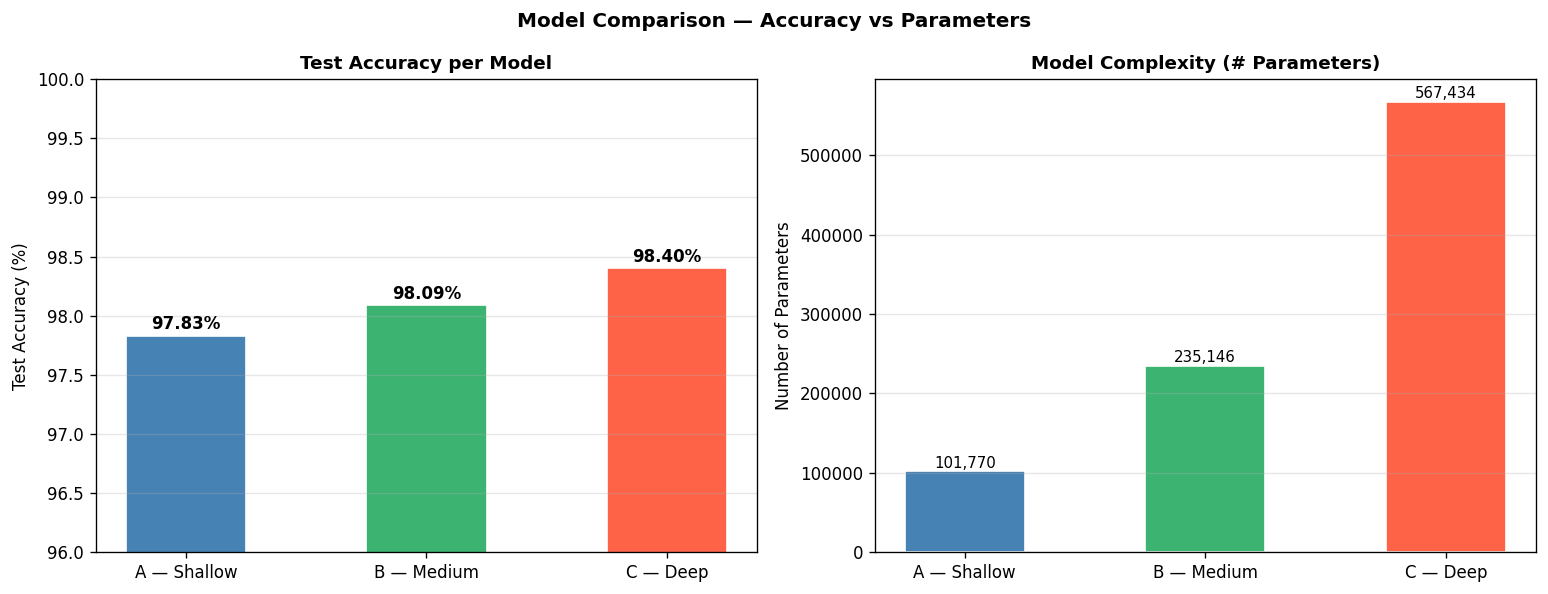

In [ ]:
# Accuracy comparison bar chart
names     = list(results.keys())
accs      = [results[k]['acc']*100 for k in names]
params    = [results[k]['params']  for k in names]
colors    = ['steelblue', 'mediumseagreen', 'tomato']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — Accuracy vs Parameters', fontsize=12, fontweight='bold')

bars = ax1.bar(names, accs, color=colors, edgecolor='white', width=0.5)
ax1.set_ylim(96, 100)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy per Model')
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(names, params, color=colors, edgecolor='white', width=0.5)
ax2.set_ylabel('Number of Parameters')
ax2.set_title('Model Complexity (# Parameters)')
ax2.grid(axis='y', alpha=0.3)
for bar, p in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{p:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 7 — Deep Analysis: Best Model (Model C)

In [ ]:
# Use best model for deep analysis
y_pred_best = results[best]['y_pred']
y_true      = y_test_raw   # original integer labels

# ── Classification Report ────────────────────────────────────
print(f'Classification Report — {best}')
print('='*55)
print(classification_report(
    y_true, y_pred_best,
    target_names=[f'Digit {i}' for i in range(10)]
))

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred_best)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Confusion Matrix — {best}', fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
ax1.set_title('Raw Counts')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# Normalized (row-wise = recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, vmin=0, vmax=1)
ax2.set_title('Normalized (Recall per Class)')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Per-class F1 score bar chart ─────────────────────────────
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_true, y_pred_best, average=None)

plt.figure(figsize=(10, 4))
bars = plt.bar(range(10), f1_per_class * 100,
               color=plt.cm.RdYlGn(f1_per_class),
               edgecolor='white')
plt.xticks(range(10), [f'Digit {i}' for i in range(10)], rotation=30)
plt.ylim(95, 100)
plt.ylabel('F1 Score (%)')
plt.title('Per-Class F1 Score', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, f1 in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{f1*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

worst_class = np.argmin(f1_per_class)
best_class  = np.argmax(f1_per_class)
print(f'Easiest digit to recognize: {best_class}  (F1={f1_per_class[best_class]*100:.2f}%)')
print(f'Hardest digit to recognize: {worst_class} (F1={f1_per_class[worst_class]*100:.2f}%)')

In [ ]:
# ── Find most confused pairs ─────────────────────────────────
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

print('Top 5 Most Confused Digit Pairs:')
print('='*40)
for rank in range(5):
    i, j     = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
    count    = cm_no_diag[i, j]
    print(f'  #{rank+1}: True={i} predicted as {j}  →  {count} times')
    cm_no_diag[i, j] = 0

---
## SECTION 8 — Visualize Wrong Predictions

In [ ]:
# Show wrongly predicted images
wrong_idxs = np.where(y_pred_best != y_true)[0]
print(f'Total wrong predictions: {len(wrong_idxs)} out of {len(y_true)}')
print(f'Error rate: {len(wrong_idxs)/len(y_true)*100:.2f}%')

# Show first 30 wrong predictions
show_n = min(30, len(wrong_idxs))
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle(f'Wrong Predictions — Model {best} (first {show_n} errors)',
             fontsize=12, fontweight='bold')

for i, idx in enumerate(wrong_idxs[:show_n]):
    ax = axes[i//10][i%10]
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f'T:{y_true[idx]}\nP:{y_pred_best[idx]}',
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('T = True label  |  P = Predicted label')

---
## SECTION 9 — Test with Your Own Handwriting (Optional)

In [ ]:
# ── Predict on a single random test image ───────────────────
best_model = results[best]['model']

# Pick a random test sample
idx         = np.random.randint(0, len(X_test))
sample      = X_test[idx:idx+1]          # shape (1, 784)
true_label  = y_true[idx]

# Get prediction probabilities
probs       = best_model.predict(sample, verbose=0)[0]
pred_label  = np.argmax(probs)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Single Prediction Demo', fontsize=12, fontweight='bold')

ax1.imshow(X_test_raw[idx], cmap='gray')
result_color = 'green' if pred_label == true_label else 'red'
ax1.set_title(f'True: {true_label}  |  Predicted: {pred_label}',
              color=result_color, fontsize=12, fontweight='bold')
ax1.axis('off')

colors_bar = ['tomato' if i != pred_label else 'steelblue' for i in range(10)]
ax2.bar(range(10), probs * 100, color=colors_bar, edgecolor='white')
ax2.set_xticks(range(10))
ax2.set_xlabel('Digit Class')
ax2.set_ylabel('Confidence (%)')
ax2.set_title('Model Confidence per Class')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Prediction: {pred_label}  |  True: {true_label}  |  Confidence: {probs[pred_label]*100:.1f}%')
print('✅ Correct!' if pred_label == true_label else '❌ Wrong!')

---
## SECTION 10 — Final Summary

In [ ]:
# Final summary table
print('='*68)
print('  PRACTICAL 3 — FINAL RESULTS SUMMARY')
print('='*68)
print(f'  {"Model":<22} {"Accuracy":>10} {"Loss":>8} {"Params":>12} {"Time":>8}')
print('-'*68)
for name in results:
    r = results[name]
    marker = ' 🏆' if name == best else ''
    print(f'  {name:<22} {r["acc"]*100:>9.2f}% {r["loss"]:>8.4f} '
          f'{r["params"]:>12,} {r["time"]:>7.1f}s{marker}')
print('='*68)

print('\nKey Observations:')
print('  • Deeper networks → higher accuracy but more parameters & time')
print('  • All models >97% — MNIST is well-suited for MLPs')
print(f'  • Easiest digit: {best_class}  |  Hardest digit: {worst_class}')
print('  • For better accuracy on MNIST → use CNN (Practical 6)')
print('\n✅ Practical 3 complete!')
print('Files saved: confusion_matrix.png, per_class_f1.png,')
print('  wrong_predictions.png, model_accuracy_comparison.png,')
print('  all_models_comparison.png, single_prediction.png')

---
## Key Learnings Table

| Concept | Explanation |
|---------|-------------|
| **Flatten** | MLP needs 1D input → 28×28 image becomes 784 numbers |
| **ReLU** | Best activation for hidden layers — avoids vanishing gradient |
| **Softmax** | Output layer for multi-class — probabilities sum to 1.0 |
| **Categorical CE** | Loss function for one-hot encoded multi-class labels |
| **Early Stopping** | Stops training when val_accuracy stops improving |
| **ReduceLROnPlateau** | Reduces learning rate when stuck — helps fine-tune |
| **Confusion Matrix** | Shows which digits are confused with each other |
| **F1 Score** | Better metric than accuracy when classes are imbalanced |
| **Depth vs Accuracy** | More layers → better accuracy but diminishing returns |

---
*Practical 3 complete ✅ — Part of [Deep Learning Portfolio](https://github.com/GauriShinde911/deep-learning-portfolio)*